load dataset

In [61]:
import pandas as pd

df = pd.read_csv("housing.csv")
print(df.info)
print(df.isnull().sum())
print(df.head())
print(df.describe())


<bound method DataFrame.info of        longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0        -122.23     37.88                41.0        880.0           129.0   
1        -122.22     37.86                21.0       7099.0          1106.0   
2        -122.24     37.85                52.0       1467.0           190.0   
3        -122.25     37.85                52.0       1274.0           235.0   
4        -122.25     37.85                52.0       1627.0           280.0   
...          ...       ...                 ...          ...             ...   
20635    -121.09     39.48                25.0       1665.0           374.0   
20636    -121.21     39.49                18.0        697.0           150.0   
20637    -121.22     39.43                17.0       2254.0           485.0   
20638    -121.32     39.43                18.0       1860.0           409.0   
20639    -121.24     39.37                16.0       2785.0           616.0   

       population  

visualisasi

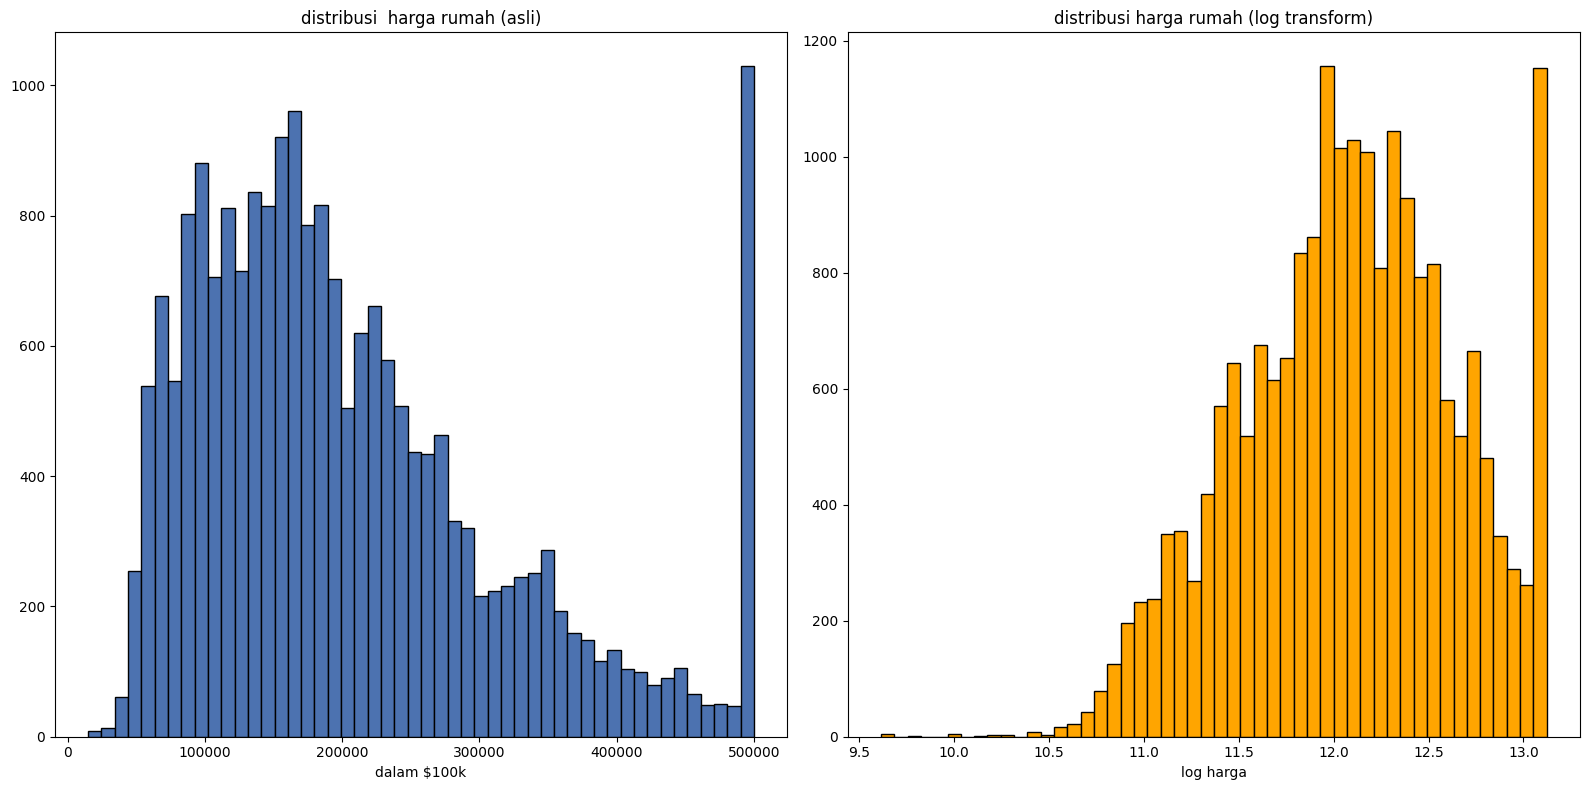

In [62]:
import numpy as np
import matplotlib.pyplot as plt
fig , axes = plt.subplots( 1, 2, figsize = (16, 8))
axes[0].hist(df['median_house_value'], bins = 50, color = '#4C72B0', edgecolor = 'black')
axes[0].set_title("distribusi  harga rumah (asli)")
axes[0].set_xlabel("dalam $100k")

#log transformasi untuk lebih normal
df['median_house_value_log'] = np.log1p(df['median_house_value'])
axes[1].hist(df['median_house_value_log'], bins = 50, color = 'orange', edgecolor = 'black')
axes[1].set_title('distribusi harga rumah (log transform)')
axes[1].set_xlabel('log harga')
plt.tight_layout()
plt.show()

heatmap korelasi

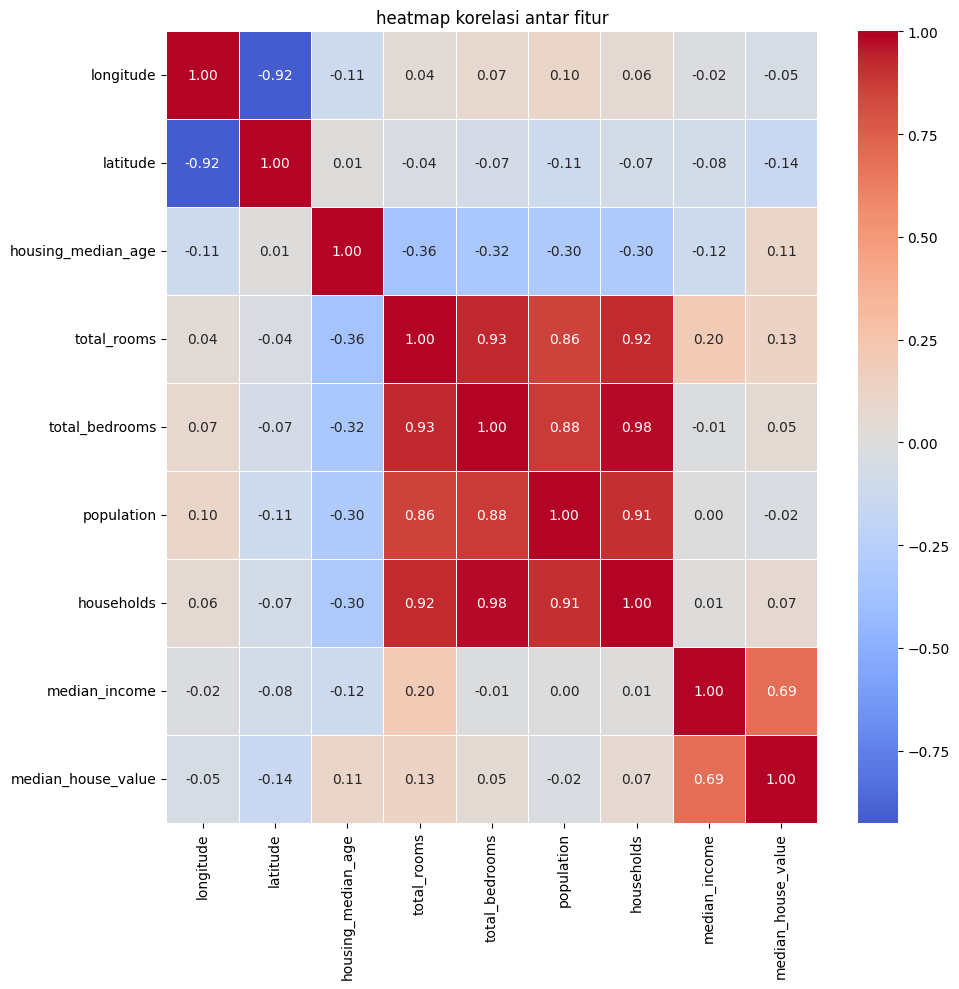

In [63]:
import seaborn as sns
plt.figure(figsize=(10, 10))
corr = df.drop(columns=['median_house_value_log', 'ocean_proximity']).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center = 0, linewidth=0.5)
plt.title ("heatmap korelasi antar fitur", fontsize = 12)
plt.tight_layout()
plt.show()

pendapatan dan harga rumah

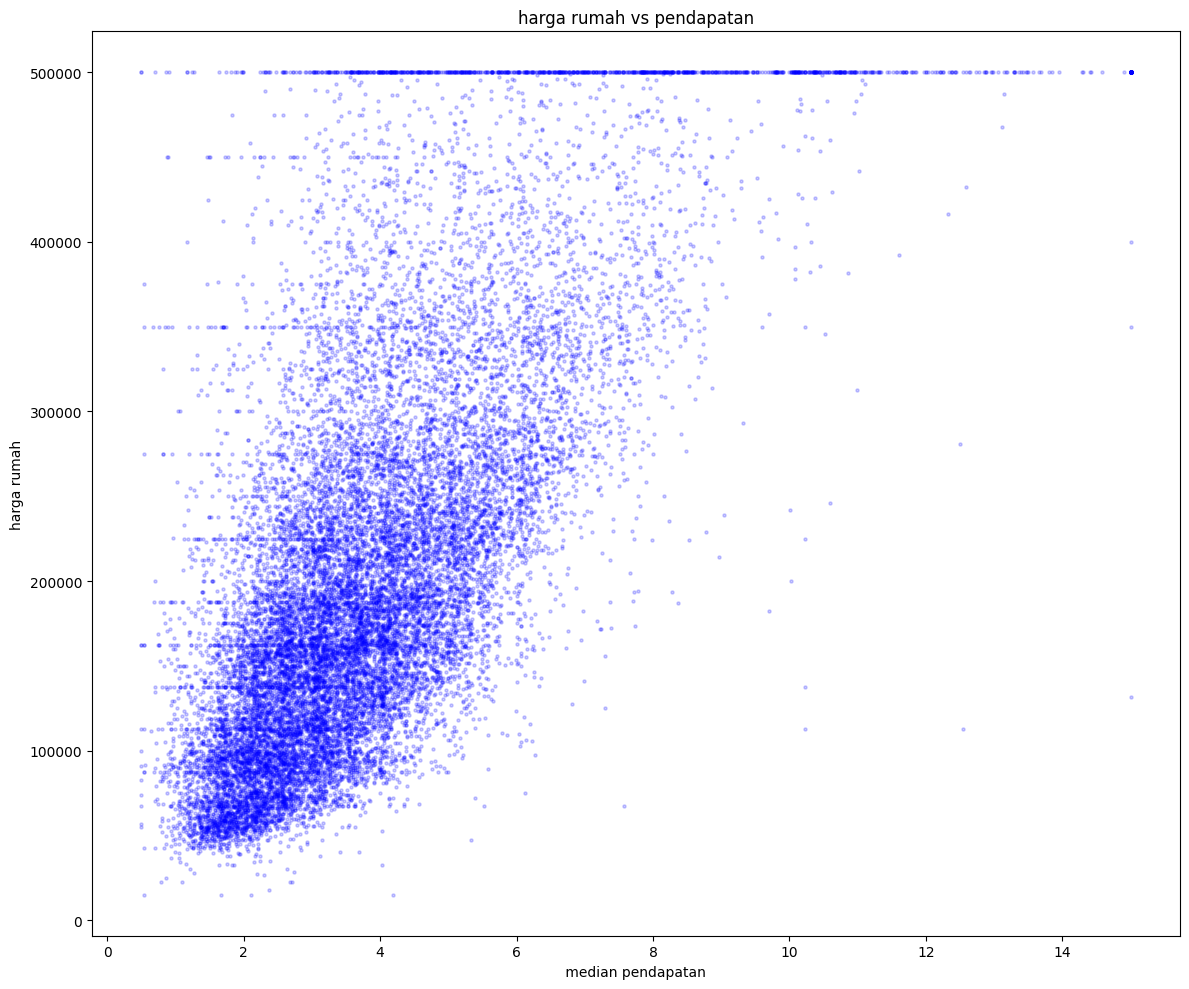

In [64]:
plt.figure(figsize=(12,10))
plt.scatter(df['median_income'], df['median_house_value'], alpha = 0.2, color = 'blue', s=5)
plt.xlabel(' median pendapatan ')
plt.ylabel('harga rumah')
plt.title('harga rumah vs pendapatan')
plt.tight_layout()
plt.show()

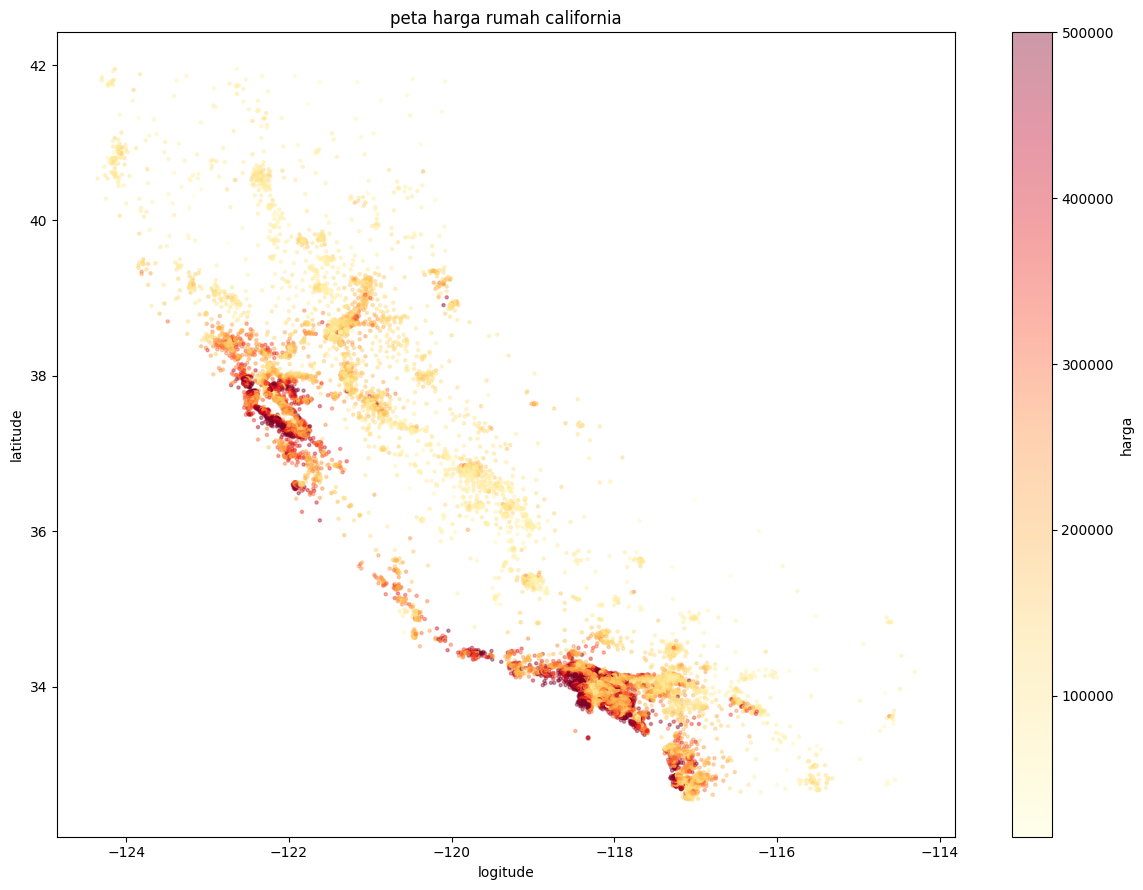

In [65]:
plt.figure(figsize=(12,9))
scatter = plt.scatter(df["longitude"], df["latitude"], c = df["median_house_value"], cmap = "YlOrRd", alpha = 0.4, s=5)
plt.colorbar(scatter, label = "harga")
plt.title("peta harga rumah california")
plt.xlabel("logitude")
plt.ylabel("latitude")
plt.tight_layout()
plt.show()

PREPOCECING DATA

In [66]:
from sklearn.preprocessing import StandardScaler 
df = df.drop(columns=['ocean_proximity'])
df = df.rename(columns={'median_house_value_log' : 'target'})

X = df.drop(columns=['target'])
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Fitur yang digunakan:", list(X.columns))
print("Jumlah data:", len(df))


Fitur yang digunakan: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Jumlah data: 20640


train model

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

models = {
    "lr" : LinearRegression(),
    "ridge" : Ridge(alpha=1.0),
    "lasso" : Lasso(alpha = 0.01),
    "dt" : DecisionTreeRegressor(max_depth=6, random_state=42),
    "rf" : RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)
}

for nama, model in models.items():
    model.fit(X_train, y_train)



KeyboardInterrupt: 

evaluasi model

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)
def evaluasi(nama,model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"model {nama}")
    print(f"mae : {mae}")
    print(f"rmse : {rmse}")
    print(f"r2 : {r2}")
    return {"MAE": mae, "RMSE": rmse, "R2": r2}  

hasil = {}
for nama, model in models.items():
    hasil[nama] = evaluasi(nama, model, X_test, y_test)

model lr
mae : 0.2631258582235896
rmse : 0.12250949959527228
r2 : 0.6225382307421905
model ridge
mae : 0.26313077748515074
rmse : 0.12250295942641909
r2 : 0.6225583815363309
model lasso
mae : 0.27013545060705035
rmse : 0.12613616382343645
r2 : 0.6113641821942062
model dt
mae : 0.2483083574935531
rmse : 0.11268249383371964
r2 : 0.6528160377164791
model rf
mae : 0.19939972985154075
rmse : 0.07665359063250587
r2 : 0.7638240296818086


aktual vs prediksi

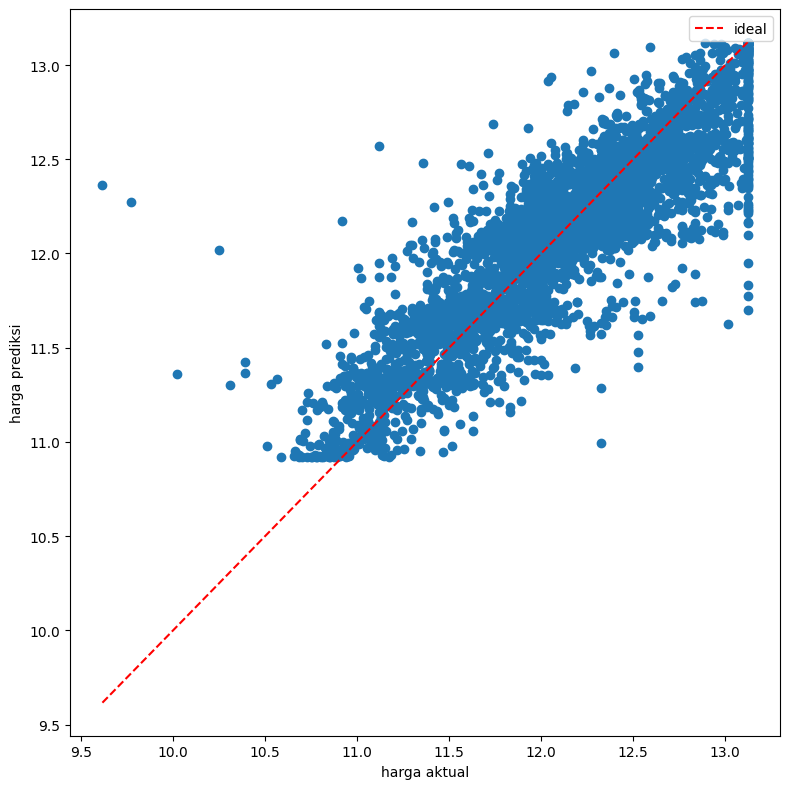

In [ ]:
y_pred_rf = models['rf'].predict(X_test)
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], "r--", linewidth = 1.5, label='ideal')
plt.xlabel("harga aktual")
plt.ylabel("harga prediksi")
plt.legend()
plt.tight_layout()
plt.show()

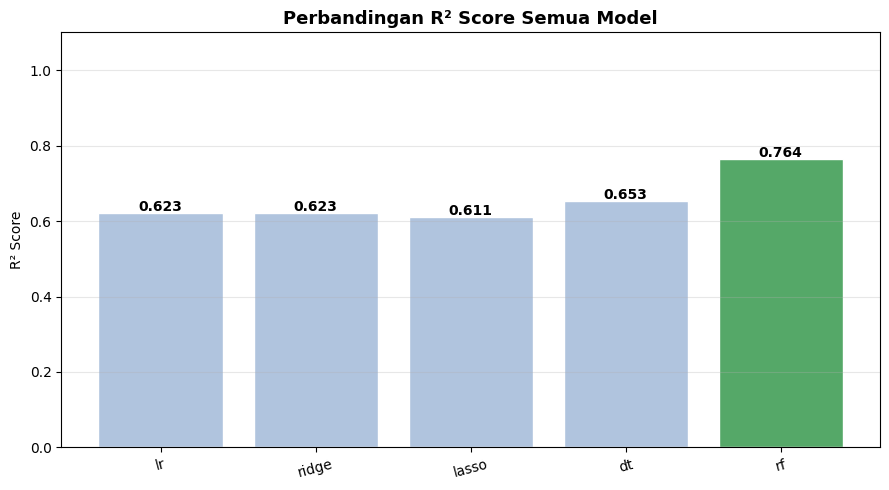

In [ ]:
r2_scores = {n: v["R2"] for n, v in hasil.items()}
plt.figure(figsize=(9, 5))
colors = ["#55A868" if v == max(r2_scores.values()) else "#B0C4DE"
          for v in r2_scores.values()]
bars = plt.bar(r2_scores.keys(), r2_scores.values(), color=colors, edgecolor="white")
for bar, val in zip(bars, r2_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f"{val:.3f}", ha="center", fontweight="bold", fontsize=10)
plt.ylim(0, 1.1)
plt.ylabel("R² Score")
plt.title("Perbandingan R² Score Semua Model", fontsize=13, fontweight="bold")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

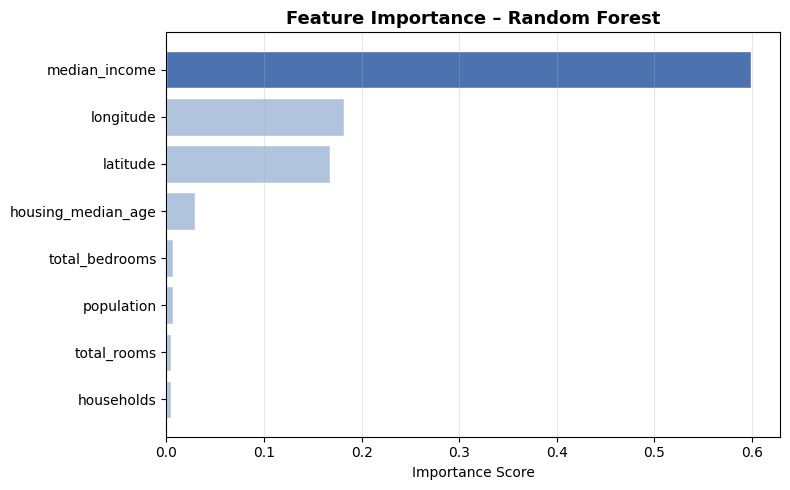

In [ ]:
rf = models["rf"]
importances = rf.feature_importances_
feat_names  = list(X.columns)
sorted_idx  = np.argsort(importances)
 
plt.figure(figsize=(8, 5))
colors_fi = ["#4C72B0" if i == sorted_idx[-1] else "#B0C4DE" for i in sorted_idx]
plt.barh([feat_names[i] for i in sorted_idx],
         [importances[i] for i in sorted_idx],
         color=colors_fi, edgecolor="white")
plt.xlabel("Importance Score")
plt.title("Feature Importance – Random Forest", fontsize=13, fontweight="bold")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
rumah_baru = [[5.0, 20.0, 6.0, 1.0, 800.0, 3.0, 34.0, -118.0]]
 
rumah_scaled = scaler.transform(rumah_baru)
prediksi_log = models["rf"].predict(rumah_scaled)
 
# Kembalikan dari log ke harga asli
harga_asli = np.expm1(prediksi_log[0]) * 100_000  # dalam dollar
 
print(f"\nPrediksi Harga Rumah: ${harga_asli:,.0f}")


Prediksi Harga Rumah: $6,606,627,682


c:\Users\evans\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
